In [76]:
## IMPORTS 
import evotoon
from data_classes import CatParam, IntParam, FloatParam

import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.layers.experimental import preprocessing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import seaborn as sns#

import random

In [77]:
## MAKE SEED
SEED = evotoon.make_seed(39)
separator = "--------------------------------------------------------"

In [82]:
## PROTOTYPE EXAMPLE WITH AntKnapsackClean-Master
poblation_size = 100

# Parameter settings
float_params = [
	FloatParam("tau_max", 0.02, 4.0),
	FloatParam("rho", 0.001, 1.0),
	FloatParam("alpha", 1, 10),
	FloatParam("beta", 1, 10),	
]
int_params = [
	IntParam("total_ants", 2, 50),
]

initial_batch = evotoon.initialization(poblation_size, float_params, int_params)

# SET ENVIRONMENT FOR THE ILSMKP ALGORITHM TO TUNE
instance_list = [
	"./AntKnapsackClean-master/instances/weing1.txt",
	"./AntKnapsackClean-master/instances/weing2.txt",
	"./AntKnapsackClean-master/instances/weing3.txt",
	"./AntKnapsackClean-master/instances/weing4.txt",
	"./AntKnapsackClean-master/instances/weing7.txt",
]

seed_list = [SEED + i for i in range(len(instance_list))]
print(separator, "Instances running and seeds", separator)
for ins,seed in zip(instance_list,seed_list):
	print("instance:", ins, "seed:", seed)

function_kwargs = {
	"executable_path": "./AntKnapsackClean-master/AntKnapsack",
	"instance_list": instance_list,
	"seed_list": seed_list,
	"evaluations": 10,
	"tau_min": 0.01
}

print(pd.DataFrame(initial_batch))
# EVALUATE BATCH
# Make inputs / outputs
X = pd.DataFrame(initial_batch).values
y = np.array([evotoon.configuration_evaluation(evotoon.execute_AntKnapsack, **{**conf, **function_kwargs}) for conf in initial_batch])
# need to standarize this somehow
y = y/np.linalg.norm(y)

normalizer = preprocessing.Normalization(axis=-1)
normalizer.adapt(np.array(X))

# Create model
model = Sequential()
model.add(normalizer)
model.add(Dense(16, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(units=1))


# Compile model
model.compile(loss='mean_squared_error', optimizer="adam")


for i in range(10):
	# Update model
	history = model.fit(X, y, epochs=50, verbose=0, validation_split = 0.2)
	# Generate configurations from model
	generated_X = []
	for conf in X:
		mutated_gen = random.randint(0, len(float_params)-1)
		mutation = np.copy(conf)
		mutation[mutated_gen] = random.uniform(float_params[mutated_gen].min_val, float_params[mutated_gen].max_val)
		generated_X.append(mutation)

	generated_X = np.array(generated_X)

	# Evaluate current batch
	A = model.predict(generated_X)
	B = np.array([evotoon.configuration_evaluation(evotoon.execute_AntKnapsack, **{**{a : b for a,b in zip(initial_batch[0].keys(), conf)}, **function_kwargs}) for conf in X])
	#can't actually do this
	B = B/np.linalg.norm(B)
	B = B.reshape(B.size, 1)
	
	# Select configurations for next step
	partition_A = np.argpartition(A[:, -1], -poblation_size//2)[-poblation_size//2:]
	generated_X = generated_X[partition_A]

	partition_B = np.argpartition(B[:, -1], - (poblation_size - poblation_size//2))[-(poblation_size-poblation_size//2):] 
	X = X[partition_B]
	X = np.concatenate((generated_X, X), axis=0)
	Y = np.concatenate((A[partition_A], B[partition_B]), axis=0)

	print(np.amax(Y))



-------------------------------------------------------- Instances running and seeds --------------------------------------------------------
instance: ./AntKnapsackClean-master/instances/weing1.txt seed: 39
instance: ./AntKnapsackClean-master/instances/weing2.txt seed: 40
instance: ./AntKnapsackClean-master/instances/weing3.txt seed: 41
instance: ./AntKnapsackClean-master/instances/weing4.txt seed: 42
instance: ./AntKnapsackClean-master/instances/weing7.txt seed: 43
     tau_max       rho     alpha      beta  total_ants
0   2.214740  0.989313  5.045852  9.884383          27
1   0.397416  0.571015  2.846391  8.679072           4
2   2.950981  0.816079  8.193331  3.681749          47
3   0.247885  0.304341  6.975439  1.446589          38
4   3.325490  0.257058  2.156527  1.509573          35
..       ...       ...       ...       ...         ...
95  2.768475  0.949068  3.621149  9.404220          40
96  3.858139  0.229660  1.037849  9.588678          43
97  1.241499  0.196192  5.847898 

In [81]:

final_partition = np.argpartition(Y[:, -1], - (poblation_size - poblation_size//2))[-(poblation_size-poblation_size//2):] 
final_Y = Y[final_partition]
final_Y

array([[0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.1       ],
       [0.10031338],
       [0.10008946],
       [0.10033283],
       [0.10082541],
       [0.10013215],
       [0.10027923],
       [0.10017473],
       [0.11261626],
       [0.10015623],
       [0.10112488],
       [0.1003965 ],
       [0.10027806],
       [0.10103908],
       [0.10092552],
       [0.10027136],
       [0.1002332 ],
       [0.10024378],
       [0.10087257],
       [0.10047123],
       [0.10157527],
       [0.10008398],
       [0.10041906],
       [0.1011864 ],
       [0.100

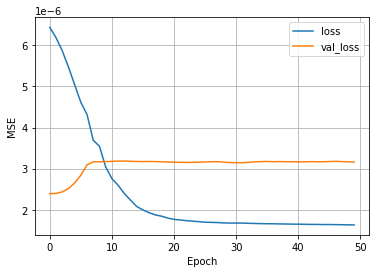

In [79]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)

plot_loss(history)
